In [1]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt 
import seaborn as sns
import datetime as dt
#loading the current file

df = pd.read_pickle('data_frame.pkl')

c:\Users\mstaw\anaconda3\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
#RFM
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm_table = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', 'max'),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum'))

rfm_table['Recency'] = (snapshot_date - rfm_table['Recency']).dt.days

In [42]:
#Creating 3 new columns 
rfm_table['R_score'] = pd.qcut(rfm_table['Recency'], 4, labels=[4, 3, 2, 1])

rfm_table['F_score'] = pd.qcut(rfm_table['Frequency'].rank(method='first'), 4, labels=[1, 2, 3, 4])

rfm_table['M_score'] = pd.qcut(rfm_table['Monetary'], 4, labels=[1, 2, 3, 4])

rfm_table

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346.0,326,2,77183.60,1,2,4
12347.0,2,7,4310.00,4,4,4
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,3,1,4
12350.0,310,1,334.40,1,1,2
...,...,...,...,...,...,...
18280.0,278,1,180.60,1,2,1
18281.0,181,1,80.82,1,2,1
18282.0,8,3,178.05,4,3,1


C:\Users\mstaw\AppData\Local\Temp\ipykernel_13596\1320233218.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rfm_table, x='segment_names', y='Monetary',palette='Set3')


<function matplotlib.pyplot.show(close=None, block=None)>

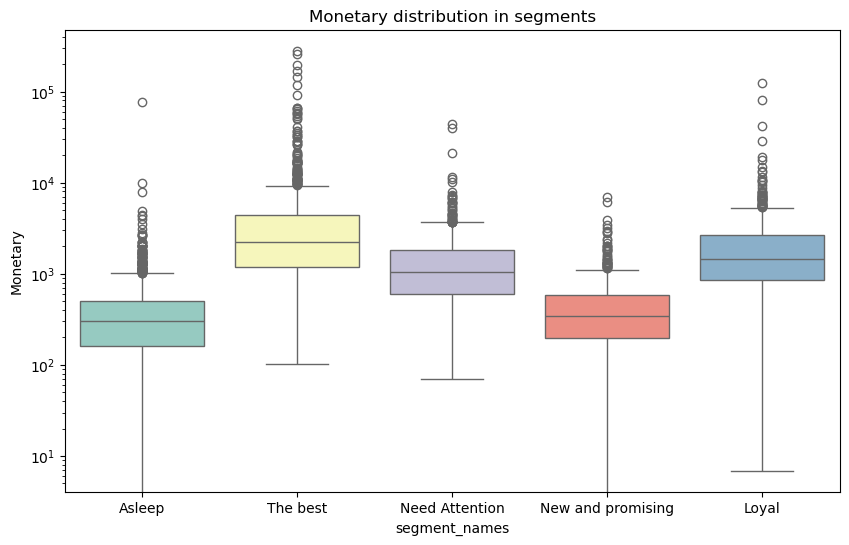

In [ ]:
#New clumn to sort by R and F
rfm_table['RF_Score'] = rfm_table['R_score'].astype(str) + rfm_table['F_score'].astype(str)

# Defining a function
def segmentation(rf_string):
    if rf_string in ['44', '43']:
        return 'The best'
    elif rf_string in ['34', '33']:
        return 'Loyal'
    elif rf_string in ['41', '42', '31', '32']:
        return 'New and promising'
    elif rf_string in ['11', '12', '21', '22']:
        return 'Asleep'
    else:
        return 'Need Attention' # Cała reszta, która nie złapała się wyżej

rfm_table['segment_names'] = rfm_table['RF_Score'].apply(segmentation)

#Plot
plt.figure(figsize=(10, 6))
sns.boxplot(data=rfm_table, x='segment_names', y='Monetary',palette='Set3')
plt.title('Monetary distribution in segments')
plt.yscale('log')
plt.show

In [65]:
Final_table = rfm_table.groupby('segment_names')['Monetary'].sum().reset_index().sort_values(by='Monetary',ascending=False)
Final_table

,segment_names,Monetary
4,The best,5181108.520
1,Loyal,1628367.591
2,Need Attention,1049792.362
0,Asleep,726495.181
3,New and promising,325644.250


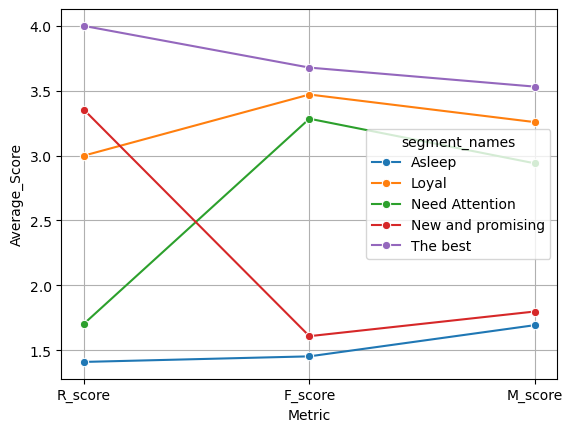

In [53]:
rfm_table[['R_score','F_score','M_score']] = rfm_table[['R_score','F_score','M_score']].astype(int)
snake_df = rfm_table.groupby('segment_names')[['R_score', 'F_score', 'M_score']].mean().reset_index()

snake_melted = pd.melt(frame=snake_df, 
                       id_vars='segment_names', 
                       var_name='Metric', 
                       value_name='Average_Score')
snake_melted


#plot
sns.lineplot(snake_melted,x='Metric',y='Average_Score',hue='segment_names',marker='o')
plt.grid(True)
plt.show()

In [57]:
#How many people in each group
count_of_segments = rfm_table.segment_names.value_counts()
count_of_segments

segment_names
Asleep               1513
The best              893
New and promising     673
Need Attention        654
Loyal                 639
Name: count, dtype: int64

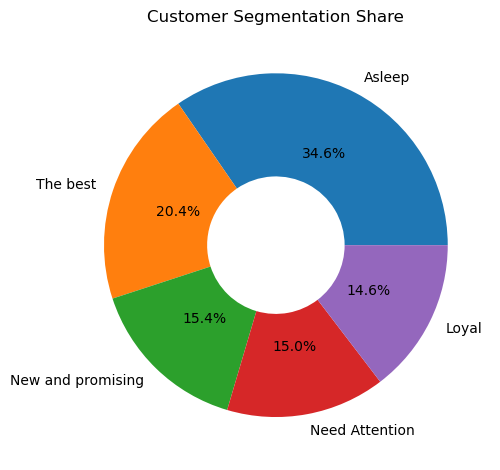

In [64]:
#plot
plt.pie(count_of_segments,labels=count_of_segments.index,autopct='%1.1f%%',wedgeprops={'width': 0.6})
plt.title('Customer Segmentation Share')
plt.tight_layout()
plt.show()